In [94]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)

import SPM_eqs
importlib.reload(SPM_eqs)

from IPython.display import display, Math

In [50]:
#sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
sol, model,params = sim_PyBaMM.simulate(0.5)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
V_true = sol.observe(model.variables['Terminal voltage [V]'])(t)
I = sol.observe(model.variables['Current [A]'])(t)
ocp_p = sol.observe(model.variables['X-averaged positive electrode open-circuit potential [V]'])(t)
ocp_n = sol.observe(model.variables['X-averaged negative electrode open-circuit potential [V]'])(t)
cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1,:]
cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1,:]
jn0_true = sol.observe(model.variables['X-averaged negative electrode exchange current density [A.m-2]'])(t)
jp0_true = sol.observe(model.variables['X-averaged positive electrode exchange current density [A.m-2]'])(t)
OCV_true = sol.observe(model.variables['Surface open-circuit voltage [V]'])(t)

In [29]:
cn_norm = cn / params['Maximum concentration in negative electrode [mol.m-3]']
cp_norm = cp / params['Maximum concentration in positive electrode [mol.m-3]']

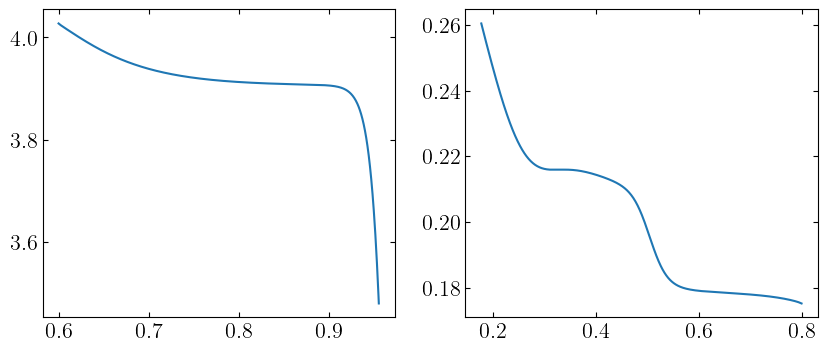

In [51]:
f, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(cp_norm, ocp_p, label='Positive Electrode')
ax[1].plot(cn_norm, ocp_n, label='Negative Electrode')

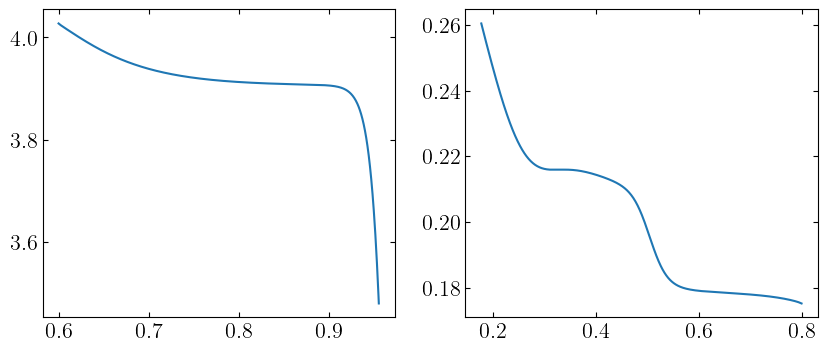

In [49]:
f, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(cp_norm, ocp_p, label='Positive Electrode')
ax[1].plot(cn_norm, ocp_n, label='Negative Electrode')


In [31]:
from pysr import PySRRegressor

In [32]:

cn_norm = cn_norm.reshape(-1,1)
cp_norm = cp_norm.reshape(-1,1)
ocp_n = ocp_n.reshape(-1,1)
ocp_p = ocp_p.reshape(-1,1)

print(cn_norm.shape, ocp_n.shape)
print(cp_norm.shape, ocp_p.shape)

(1000, 1) (1000, 1)
(1000, 1) (1000, 1)


In [82]:
model_n = PySRRegressor(
    model_selection="accuracy",  # "best" or "accuracy"
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log", "sqrt","square","cube"],
    loss="loss(x, y) = (x - y)^2",
    populations=10,
    verbosity=0,)

model_p = PySRRegressor(
    model_selection="accuracy",  # "best" or "accuracy"
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log", "sqrt","square","cube"],
    loss="loss(x, y) = (x - y)^2",
    populations=10,
    verbosity=0,)

In [83]:
model_n.fit(cn_norm, ocp_n)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


,model_selection,'accuracy'
,binary_operators,"['+', '-', ...]"
,unary_operators,"['exp', 'log', ...]"
,expression_spec,None
,niterations,100
,populations,10
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


In [84]:
model_p.fit(cp_norm, ocp_p)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


,model_selection,'accuracy'
,binary_operators,"['+', '-', ...]"
,unary_operators,"['exp', 'log', ...]"
,expression_spec,None
,niterations,100
,populations,10
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


In [85]:
display(Math('\\mathrm{Negative:}\\quad' + model_n.latex()))
display(Math('\\mathrm{Positive:}\\quad' + model_p.latex()))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [106]:
sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
V_true = sol.observe(model.variables['Terminal voltage [V]'])(t)
I = sol.observe(model.variables['Current [A]'])(t)
ocp_p = sol.observe(model.variables['X-averaged positive electrode open-circuit potential [V]'])(t)
ocp_n = sol.observe(model.variables['X-averaged negative electrode open-circuit potential [V]'])(t)
cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1,:]
cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1,:]
OCV_true = sol.observe(model.variables['Surface open-circuit voltage [V]'])(t)

In [110]:
cn_norm = cn_norm.reshape(-1,1)
cp_norm = cp_norm.reshape(-1,1)
ocp_n = ocp_n.reshape(-1,1)
ocp_p = ocp_p.reshape(-1,1)

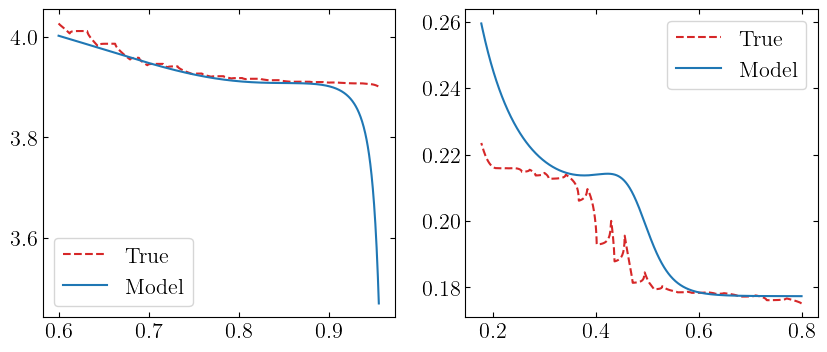

In [111]:
ocpn_pred = model_n.predict(cn_norm)
ocpp_pred = model_p.predict(cp_norm)

f, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(cp_norm, ocp_p, label='True',color = 'tab:red',ls = '--')
ax[0].plot(cp_norm, ocpp_pred, label='Model',color = 'tab:blue')
ax[1].plot(cn_norm, ocp_n, label='True',color = 'tab:red',ls = '--')
ax[1].plot(cn_norm, ocpn_pred, label='Model',color = 'tab:blue')
ax[0].legend()
ax[1].legend()  

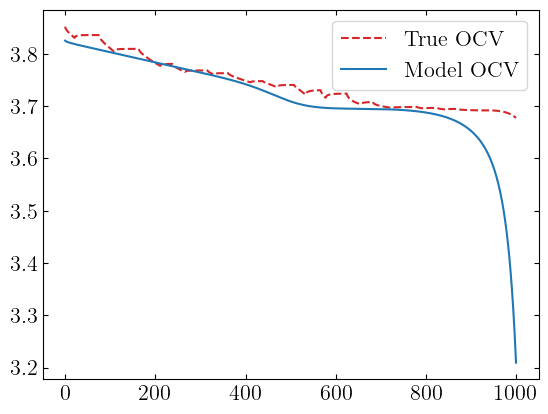

In [112]:
plt.plot(OCV_true, label='True OCV',color = 'tab:red',ls = '--')
plt.plot(ocpp_pred-ocpn_pred, label='Model OCV',color = 'tab:blue')
plt.legend()